In [22]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

# INTRODUCTION #

The purpose of this notebook is to display some results obtained by constructing Voronoi structures through the codes in voronoi.h and voronoi_clipped.h, starting from given Dealaunay meshes.

In the first part, we draw the obtained clipped Voronoi against their corresponding triangulations.

In the second part instead, we see the computational cost of generating both unclipped and clipped Voronoi.

# DATA DEFINITION #

In [23]:
MESHES_PATH = "../data/mesh"
VORONOI_PATH = "data/"

COMPUTATIONAL_COSTS_PATH = "../data/computational_times"

# FUNCTIONS DEFINITIONS #

In [24]:
# Function to plot the Voronoi
def plot_voronoi(shape: str,):
    points_path = os.path.join(MESHES_PATH, shape, "points.csv")
    edges_path = os.path.join(MESHES_PATH, shape, "edges.csv")
    df_points = pd.read_csv(f"../data/mesh/{shape}/points.csv").rename(columns={'Unnamed: 0': 'id'})

    _ = plt.figure(figsize=(10, 8))
    _ = plt.scatter(df_points['V1'], df_points['V2'], color='black', s=1)
    id2TriaNodes = {}
    for _, row in df_points.iterrows():
        id2TriaNodes[row['id']] = (row['V1'], row['V2'])

    df_edges = pd.read_csv(f"../data/mesh/{shape}/edges.csv")
    if 'Unnamed: 0' in df_edges.columns:
        df_edges = df_edges.drop(columns='Unnamed: 0')
    triaEdges = []
    for _, row in df_edges.iterrows():
        triaEdges.append([id2TriaNodes[row['V1']], id2TriaNodes[row['V2']]])

    lc = LineCollection(triaEdges, colors='black', linewidths=0.5)

    # Add to current axes
    ax = plt.gca()
    ax.add_collection(lc)

    voronoi_path = os.path.join(VORONOI_PATH, f"{shape}.json")
    with open(f"data/{shape}.json", 'r') as f:
        data = json.load(f)

    nodes = data['nodes']

    xs = [item['coords'][0] for item in nodes]
    ys = [item['coords'][1] for item in nodes]

    _ = plt.scatter(xs, ys, s=5, color='red')

    id2Node = {d['id']: (d['coords'][0], d['coords'][1]) for d in nodes}
    data
    edges = [[id2Node[d['from']], id2Node[d['to']]] for d in data['edges']]
    edges

    lc = LineCollection(edges, colors='red', linewidths=1)

    # Add to current axes
    ax = plt.gca()
    ax.add_collection(lc)  
    
    plt.show()

    return data

# VORONOI PLOTTING #

**Unit Square 16**

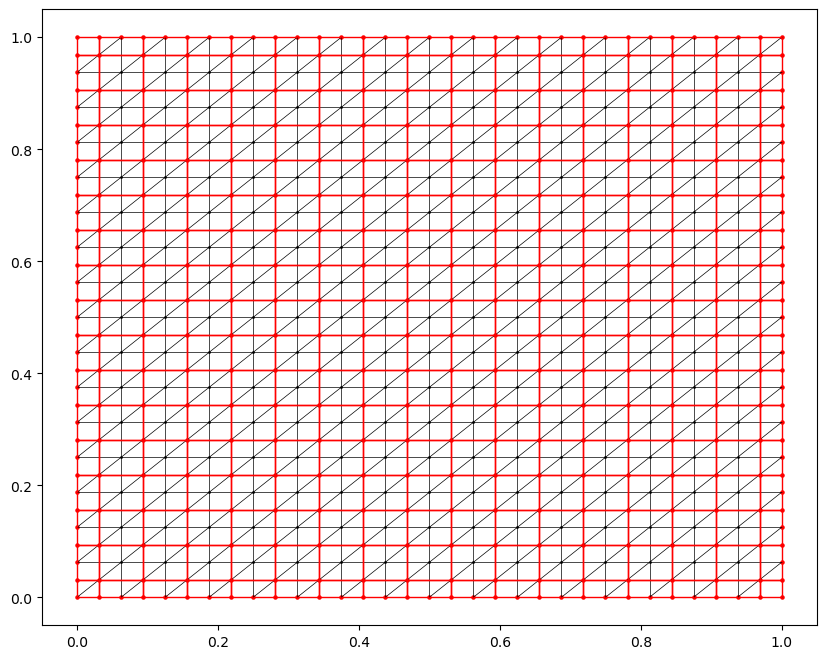

In [25]:
shape = "unit_square_16"
data = plot_voronoi(shape=shape)

**Quasi Circle**

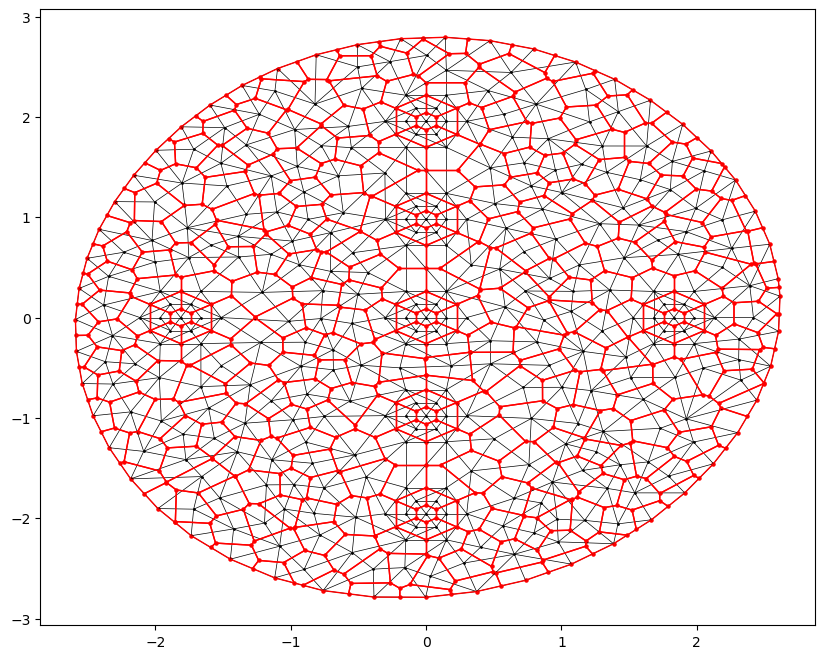

In [26]:
shape = "quasi_circle"
data = plot_voronoi(shape=shape)

**C Shaped**

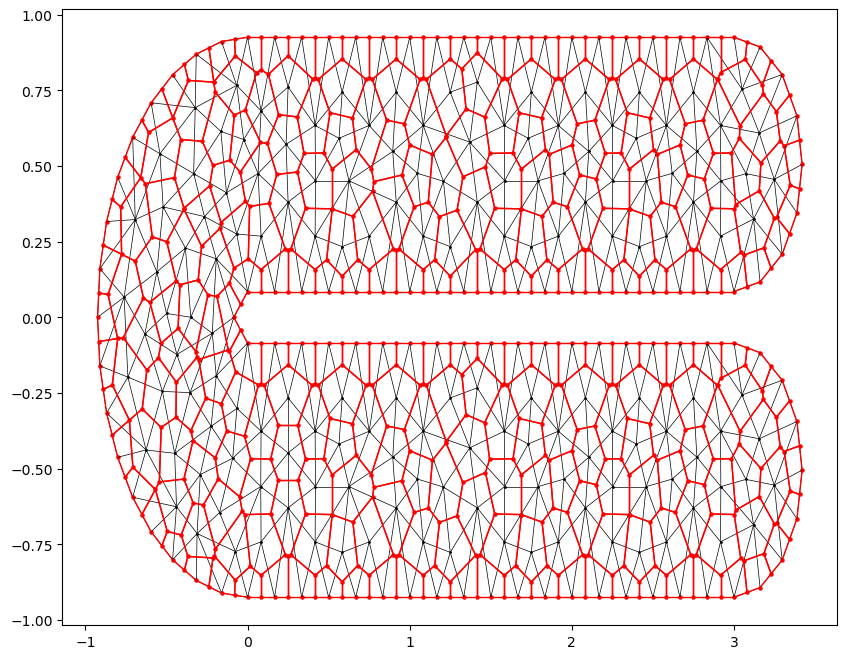

In [27]:
shape = "c_shaped"
data = plot_voronoi(shape=shape)

**North Italy**

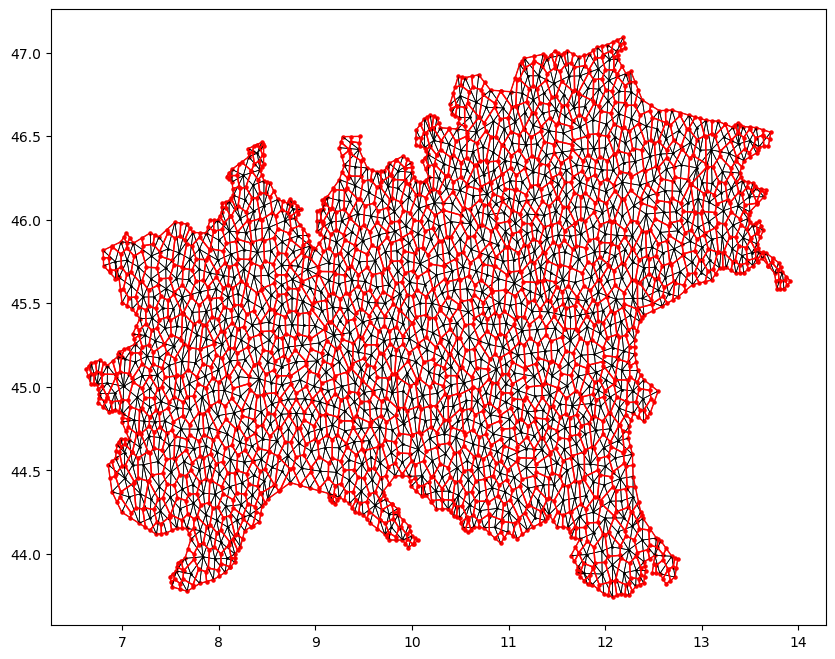

In [28]:
shape = "north_italy"
data = plot_voronoi(shape=shape)

**Brain**

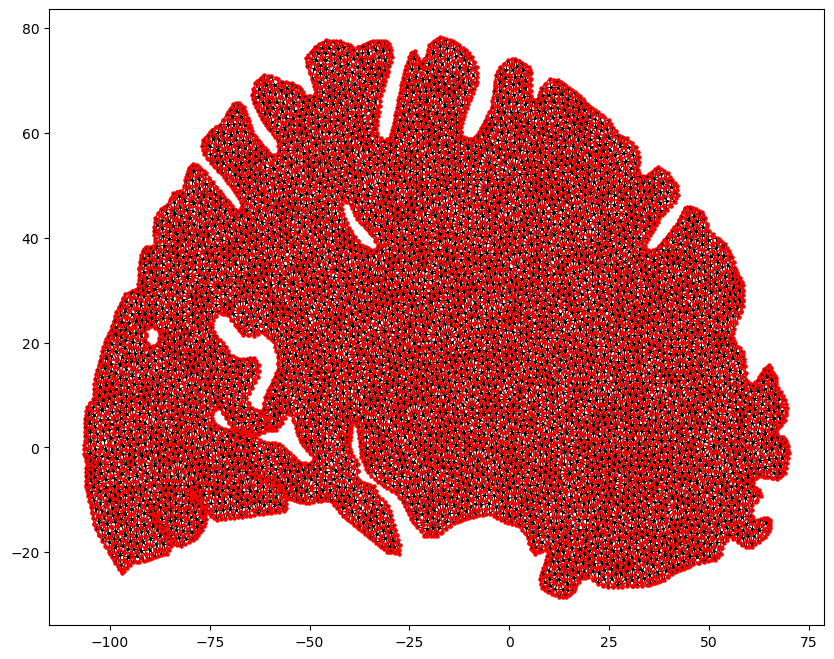

In [29]:
shape = "brain"
data = plot_voronoi(shape=shape)

# COMPUTATIONAL COSTS #

**Computational Cost Voronoi Unclipped**

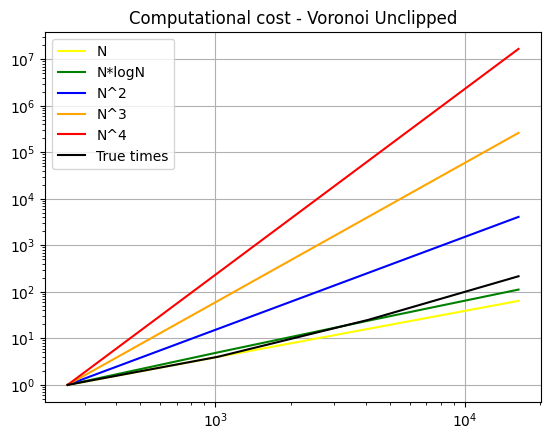

In [3]:
N = np.array([16, 32, 64, 128])
N = N**2
N_logN = N * np.log(N)
N_2 = N**2
N_3 = N**3
N_4 = N**4

times = np.loadtxt(
    os.path.join(COMPUTATIONAL_COSTS_PATH, "voronoi.txt"),
    dtype=np.int64
)

plt.loglog(N, N/N[0], color='yellow', label='N')
plt.loglog(N, N_logN/N_logN[0], color='green', label='N*logN')
plt.loglog(N, N_2/N_2[0], color='blue', label='N^2')
plt.loglog(N, N_3/N_3[0], color='orange', label='N^3')
plt.loglog(N, N_4/N_4[0], color='red', label='N^4')
plt.loglog(N, times/times[0], color='black', label='True times')
_ = plt.grid()
_ = plt.legend()
_ = plt.title("Computational cost - Voronoi Unclipped")

**Computational Cost Voronoi Clipped**

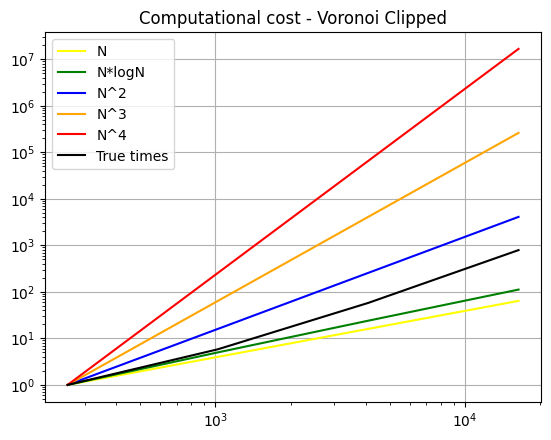

In [4]:
N = np.array([16, 32, 64, 128])
N = N**2
N_logN = N * np.log(N)
N_2 = N**2
N_3 = N**3
N_4 = N**4

times = np.loadtxt(
    os.path.join(COMPUTATIONAL_COSTS_PATH, "voronoi_clipped.txt"),
    dtype=np.int64
)

plt.loglog(N, N/N[0], color='yellow', label='N')
plt.loglog(N, N_logN/N_logN[0], color='green', label='N*logN')
plt.loglog(N, N_2/N_2[0], color='blue', label='N^2')
plt.loglog(N, N_3/N_3[0], color='orange', label='N^3')
plt.loglog(N, N_4/N_4[0], color='red', label='N^4')
plt.loglog(N, times/times[0], color='black', label='True times')
_ = plt.grid()
_ = plt.legend()
_ = plt.title("Computational cost - Voronoi Clipped")